# **Import required packages**

There are a number of required Python packages that need to be installed to successfully run the code below. Fortunately, Google Colab already has these packages installed but if you want run this code locally on your computer you would need to make sure the required packages are installed by using running the pip install command below that is correct for your operating system.

**Mac:**
python3 -m pip install numpy matplotlib pandas plotly polars rasterio requests



**Windows:**
python -m pip install matplotlib pandas plotly polars rasterio requests

In [2]:
!pip install matplotlib-venn

In [3]:

from matplotlib import pyplot as plt
import numpy as np
import pandas as pd
import plotly.express as px
import polars as pl
import rasterio
from rasterio.plot import show
import requests
import matplotlib_venn

# **Load datasets to visualize**

In [4]:
#Dive characteristics of Weddell seals 2014-2016 from https://dataverse.tdl.org/file.xhtml?fileId=62725&datasetVersionId=1894
#The data used below comes from the Texas Data Repository.
#The publication related to this dataset is:  Fuiman, L.A., T.M. Williams, and R.W. Davis. 2020. Homing tactics of Weddell seals in the Antarctic fast-ice environment. Marine Biology. (doi: 10.1007/s00227-020-03730-w)
# sealdivedatarequest = requests.get("https://dataverse.tdl.org/api/access/datafile/62725?gbrecs=true")
sealdivesdf = pd.read_csv("https://dataverse.tdl.org/api/access/datafile/62725?gbrecs=true")

In [5]:
#Portland, Oregon parks tree inventory data from https://gis-pdx.opendata.arcgis.com/datasets/PDX::parks-tree-inventory/about
pdxtreesdf = pd.read_csv("https://hub.arcgis.com/api/v3/datasets/15ae00ece1bf486a868c0f635d3acbfa_220/downloads/data?format=csv&spatialRefId=3857&where=1%3D1")

In [6]:
#Telco customer churn dataset from https://github.com/IBM/telco-customer-churn-on-icp4d/tree/master
customerchurndf = pd.read_csv("https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/refs/heads/master/data/Telco-Customer-Churn.csv")

In [7]:
#UAV orthmosaic stored in ArcGIS Online
singleimageband0 = {"bandname":"rgb",  "cmap":"RdBu", "url":"https://ut-austin.maps.arcgis.com/sharing/rest/content/items/7f886ebb895b4610961e076e8eabe092/data"}
singleimageband1 = {"bandname":"blue",  "cmap":"Blues",  "url":"https://ut-austin.maps.arcgis.com/sharing/rest/content/items/ef3529e489da4b489303f357f92d4702/data"}
singleimageband2 = {"bandname":"green",  "cmap":"Greens",  "url":"https://ut-austin.maps.arcgis.com/sharing/rest/content/items/21bfc72d87a844c8834db572bda24e58/data"}
singleimageband3 = {"bandname":"red",  "cmap":"Reds", "url":"https://ut-austin.maps.arcgis.com/sharing/rest/content/items/a88d3b517a4f48d59fc752a259d1e1e1/data"}
singleimageband4 = {"bandname":"rededge",  "cmap":"Greys",  "url":"https://ut-austin.maps.arcgis.com/sharing/rest/content/items/c9b200641847435da1893389b2ecda77/data"}
singleimageband5 = {"bandname":"nir",  "cmap":"Greys",  "url":"https://ut-austin.maps.arcgis.com/sharing/rest/content/items/6450229be3494bd9a4e24283adf8b071/data"}

multibandortho = {"bandname":"all", "cmap":"Greys", "url":"https://ut-austin.maps.arcgis.com/sharing/rest/content/items/7d6bbe91e12641c0b93534ffd038ecd6/data"}

dem = {"bandname":"dem", "cmap":"gist_earth", "url": "https://ut-austin.maps.arcgis.com/sharing/rest/content/items/f735a03cae164f1caeb32de97b017a23/data"}

# **Produce data visualizations**

*   Simple visualization with Pandas
*   Adjust title
*   X and Y label axes
*   Color
*   Saving image in different formats
*   Visualization with Matplotlib
*   Multiple subplots
*   Visualization with Plotly - linear regression




# Save an empty figure

In [8]:
from matplotlib import pyplot as plt

plt.savefig("example.jpg")

<Figure size 640x480 with 0 Axes>

# Save a figure with an empty plot in it

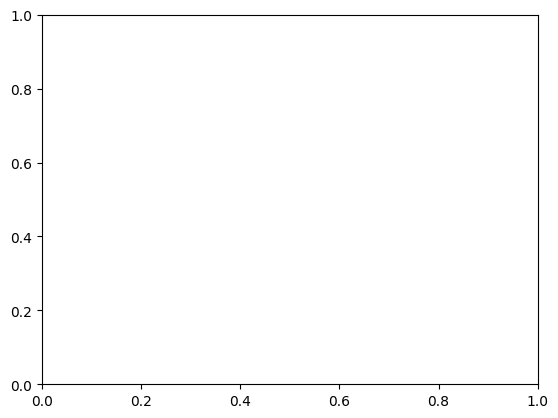

In [9]:
from matplotlib import pyplot as plt

fig, axs = plt.subplots()
plt.savefig("example.jpg")

# Save a figure with two empty subplots in it

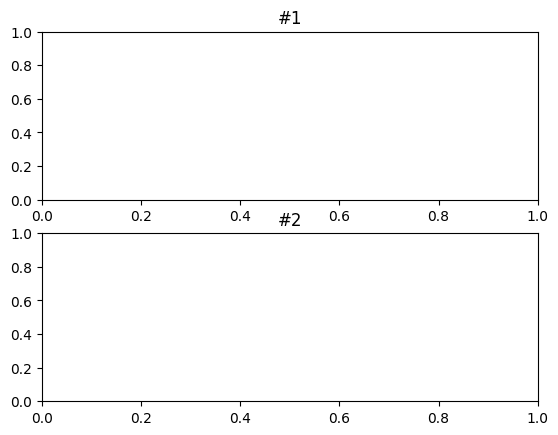

In [10]:
fig, axs = plt.subplots(2,1)
axs[0].set_title("#1")
axs[1].set_title("#2")
plt.savefig("example.jpg")

# Overwrite the figure and create a scatterplot

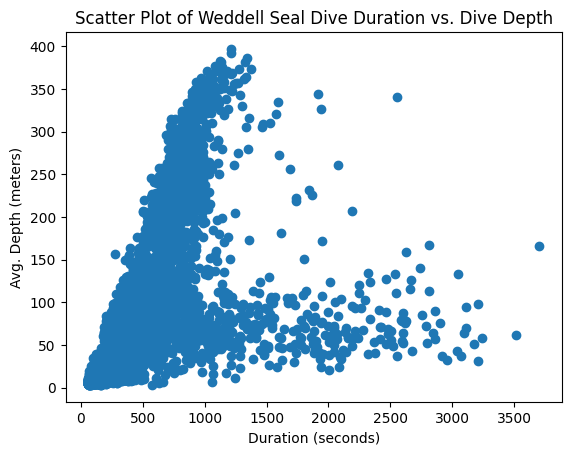

In [11]:
x = sealdivesdf['Duration'].to_list()
y = sealdivesdf['Avg.Depth'].to_list()


plt.scatter(x,y)
plt.title('Scatter Plot of Weddell Seal Dive Duration vs. Dive Depth')
plt.xlabel('Duration (seconds)')
plt.ylabel('Avg. Depth (meters)')




plt.savefig("scatterplot.png")


sealdivesdf columns: Index(['Unique', 'Divenum', 'Hole', 'Seal', 'DataFile', 'Year', 'Month', 'Day',
       'Hour', 'Minute', 'Second', 'Date', 'Julian_Day', 'HStat', 'DiveType',
       'DiveStyle', 'SurfaceInter', 'Avg.Depth', 'Max.Depth', 'Total.Dist',
       'NetDist_x2', 'NGDR', 'Duration', 'Avg.Speed', 'Max.Speed',
       'FarPoint.Vis.Ang', 'FarPoint.X', 'FarPoint.Y', 'FarPoint.Z',
       'Out.Avg.Depth', 'Out.Max.Depth', 'Out.Total.Dist', 'Out.Net.Dist',
       'Out.NGDR', 'Out.Duration', 'Out.Avg.Speed', 'Out.Max.Speed',
       'Out.Avg.Heading', 'In.Avg.Depth', 'In.Max.Depth', 'In.Total.Dist',
       'In.Net.Dist', 'In.NGDR', 'In.Duration', 'In.Avg.Speed', 'In.Max.Speed',
       'In.Avg.Heading', 'Avg.Min.Dist.Hydro', 'PathIntegration',
       'HydroDynamic', 'LandMark', 'CapturDir', 'Out_Captur_Diff',
       'Solar.Day.Night', 'Solar.Dec', 'Avg.WindDir', 'Avg.WindSp.kts',
       'Avg.WindSp.mph', 'Avg.AirTemp.C', 'Max.Air.Temp.C', 'Min.Air.Temp.C',
       'Avg.WindChill.C', '

<Axes: xlabel='DBH'>

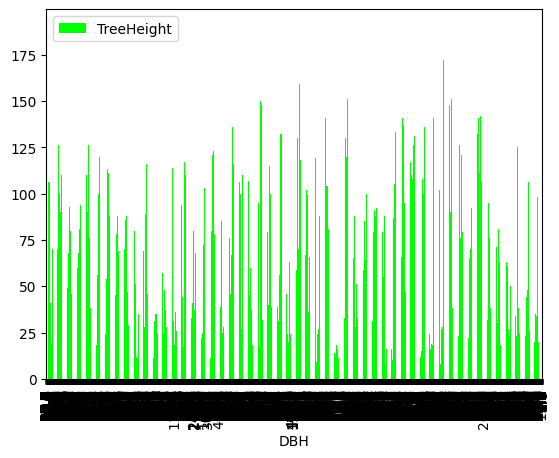

In [12]:
# # sealdivesdf.plot(kind='scatter', x='Avg.Speed', y='Total.Dist', title='title')
# fig, ax = plt.subplots()
# pdxtreesdf.plot(kind='scatter', x='DBH', y='TreeHeight', title='title', color="#009911", ax=ax)

# fig.savefig("example.jpg")


# POLARS
print("sealdivesdf columns: " + str(sealdivesdf.columns))
print("treesdf columns: " + str(pdxtreesdf.columns))
pdxtreesdf.plot.bar(x='DBH', y='TreeHeight', color="#00ff00")


# Create a scatter plot with a regression line

In [13]:
# Scatter plot with regression line
fig = px.scatter(pdxtreesdf, x='DBH', y='TreeHeight', trendline='ols', trendline_color_override="black")
fig.show()
# fig.write_image("regressionexample1.png")


# **Python for Data Visualization**

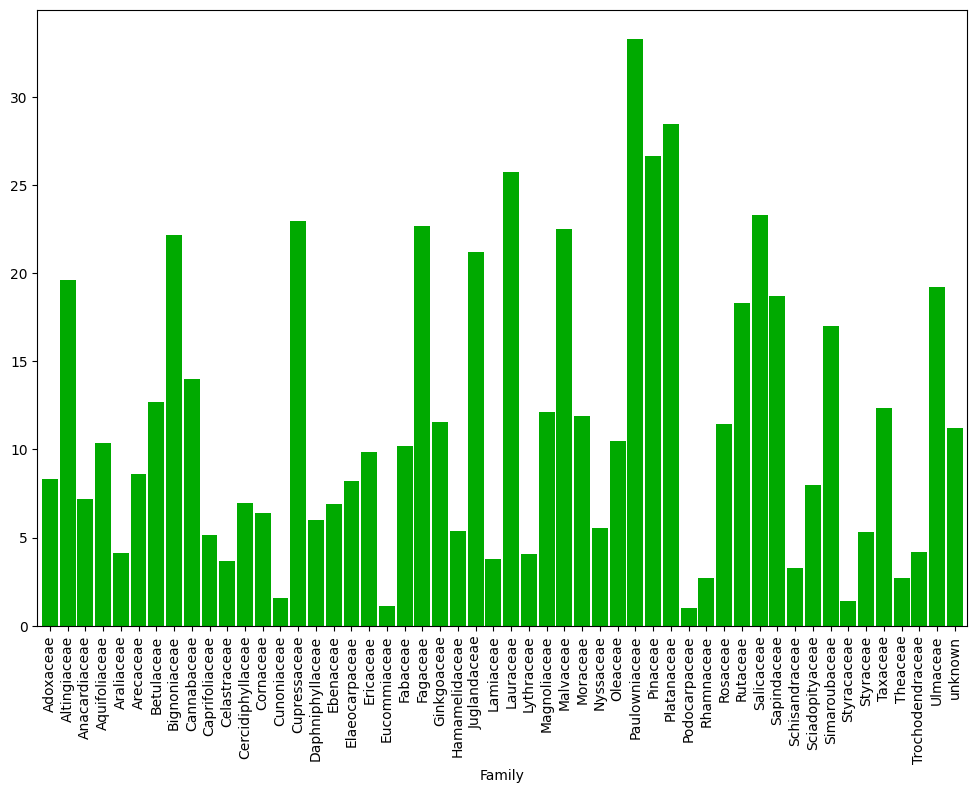

In [14]:


uniquepdxtrees = set(pdxtreesdf['Species'].items())

# Group by species and get the value counts for animal names
treespeciescounts = pdxtreesdf.groupby('Family')['DBH'].mean()

# print(treespeciescounts)

treespeciescounts.plot(kind="bar", width=.9, figsize=(12,8), color="#00aa00")
plt.savefig("example2.jpg")



### Matplotlib Histogram

Text(0, 0.5, 'Count')

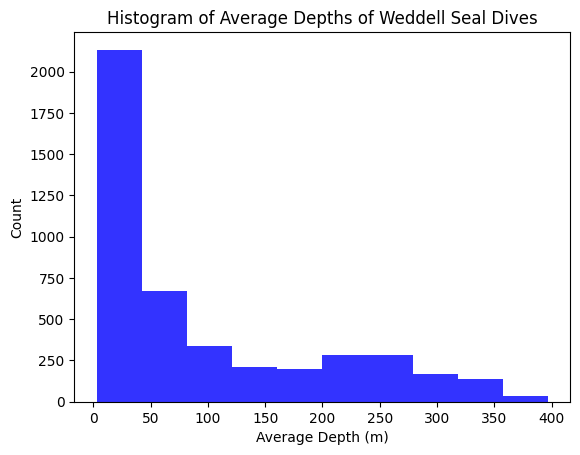

In [15]:
# plt.bar(avgdepthlist,  label="Average Weddell Seal Dive Depth (m)")
fig = plt.figure()
ax = fig.add_subplot(1,1,1)
n, bins, patches = ax.hist(sealdivesdf['Avg.Depth'].to_list(), bins=10, range=(min(sealdivesdf['Avg.Depth'].to_list()), max(sealdivesdf['Avg.Depth'].to_list())), histtype='bar')

for patch in patches:
    patch.set_facecolor('#3333ff')

plt.title('Histogram of Average Depths of Weddell Seal Dives')
plt.xlabel('Average Depth (m)')
plt.ylabel('Count')


### Plotly Histogram

In [16]:
#DIAMETER is in inches
fig = px.histogram(pdxtreesdf, x="DBH", nbins = 25, title="Histogram of Tree Trunk Diameters (in)")
fig.show()

### Plotting Data in 3 Dimensions

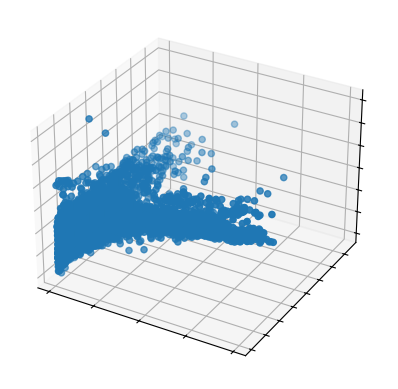

In [17]:

fig, ax = plt.subplots(subplot_kw={"projection": "3d"})
ax.scatter(sealdivesdf['Avg.Depth'].to_list(), sealdivesdf['Duration'].to_list(), sealdivesdf['Avg.Speed'].to_list())

ax.set(xticklabels=[],
       yticklabels=[],
       zticklabels=[])

plt.show()


### Matplotlib Venn Diagram

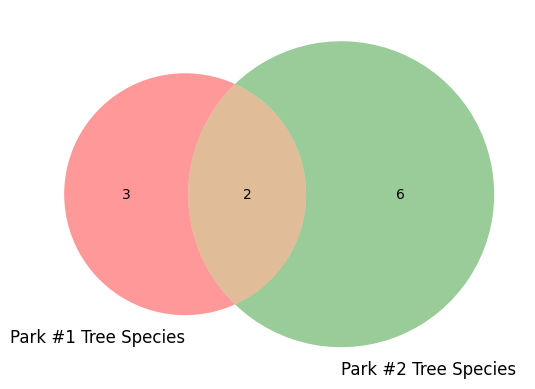

In [18]:
set1 = set(["Quercus virginiana","Quercus macrocarpa","Celtis laevigata","Carya illinoensis","Quercus shumardii"])
set2 = set(["Carya illinoensis","Quercus macrocarpa","Fraxinus albicans","Taxodium mucronatum", "Acer saccharinum", "Lagerstroemia indica", "Quercus laceyii","Quercus polymorpha"])

matplotlib_venn.venn2([set1, set2], ('Park #1 Tree Species', 'Park #2 Tree Species'))
